In [5]:
import pandas as pd

In [6]:
df = pd.read_csv("Mall_Customers.csv")

In [7]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
#Here we dont want the CustomerID column
df.drop('CustomerID', axis=1, inplace=True)

In [9]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [10]:
#size
df.shape

(199, 4)

In [11]:
#to check the missing value/null values
df.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [12]:
#To check duplicated values
df.duplicated().sum()

0

In [13]:
#To check the datatype of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  199 non-null    object
 1   Age                     199 non-null    int64 
 2   Annual Income (k$)      199 non-null    int64 
 3   Spending Score (1-100)  199 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.3+ KB


In [14]:
#To check basic statistics
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,199.000000,199.000000,199.000000
mean,38.819095,60.231156,50.311558
std,13.997382,25.914912,25.840291
min,18.000000,15.000000,1.000000
25%,28.500000,41.000000,35.000000
50%,36.000000,61.000000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [15]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


<AxesSubplot:xlabel='Gender'>

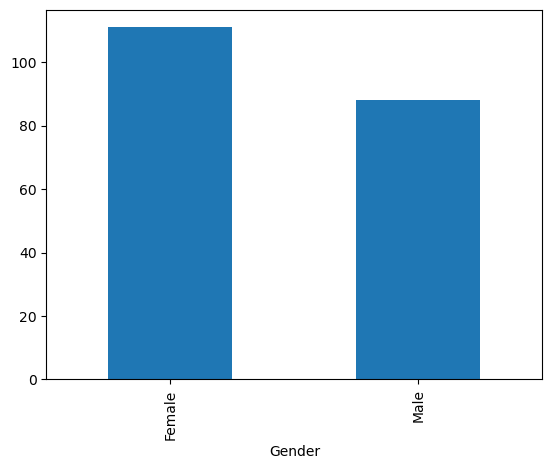

In [18]:
#here Gender column is labeled, convert to numerical form
df['Gender'].value_counts().plot(kind='bar')

In [19]:
#TO CHECK THE BALANCE OF DATASET
df['Spending Score (1-100)'].value_counts()

Spending Score (1-100)
42    8
55    7
46    6
73    6
35    5
     ..
44    1
53    1
28    1
65    1
18    1
Name: count, Length: 84, dtype: int64

In [20]:
#Convert gender column to numerical value
df['Gender'] = df['Gender'].map({'Male':1,'Female':0})

In [21]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [22]:
#split into x and y axis
X = df.drop('Spending Score (1-100)', axis=1)
y = df['Spending Score (1-100)']

In [23]:
X.shape

(199, 3)

In [24]:
y.shape

(199,)

In [25]:
#Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=5)

In [26]:
X_train.shape

(159, 3)

In [27]:
X_test.shape

(40, 3)

In [28]:
#Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
#train
model.fit(X_train,y_train)

LinearRegression()

In [33]:
#User prediction
predict = model.predict([[1,27,25]])
predict

C:\Users\CSC\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([52.74651371])

## Save Model

In [35]:
import pickle
pickle.dump(model,open("model.pkl","wb"))